In [1]:
import torch

model_ckpt_path = "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/rl/outputs/best_model_gin.pt"
config_path = "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/gnn/config/model/gin_3.yaml"

In [2]:
!pwd

/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL


In [7]:
from omegaconf import OmegaConf

from src.gnn.model.model import GraphRegressorV2


model = GraphRegressorV2(
    gnn_type="gin",
    config=OmegaConf.load(config_path).model_config,
)
model.load_state_dict(torch.load(model_ckpt_path))
model.eval()

GraphRegressorV2(
  (coord_embedder): CoordinateEmbedder(
    (embedder): Linear(in_features=3, out_features=64, bias=True)
  )
  (node_mlp): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
  )
  (gnn_layers): ModuleList(
    (0-3): 4 x GINConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    ))
  )
  (global_mlp): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc_out): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [8]:
torch.save(model, "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/rl/outputs/best_model_gin_with_class.pt")

In [21]:
import pandas as pd

modules_df = pd.DataFrame(sample.x.numpy(), columns=['x', 'y', 'z', 'theta_init'])
modules_df

,x,y,z,theta_init
0,0.000000,65.939003,53.101002,6.651000
1,-9.444000,65.000999,52.630001,8.284000
2,-19.681000,61.889000,52.936001,10.930000
3,-30.409000,57.433998,53.105999,14.094000
4,-40.766998,51.227001,53.310001,17.921000
...,...,...,...,...
1844,129.358002,88.128998,-4.083000,70.888000
1845,102.100998,102.301003,-3.775000,71.279999
1846,74.915001,114.113998,-3.405000,71.702003
1847,48.148998,122.334000,-3.331000,72.015999


In [22]:
from src.rl.src.datasets import PyGDataset

# 학습 데이터에서 추출
dataset = PyGDataset("/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/gnn/datapyg_dataset_rl.pt")
sample = dataset.get_item(0)

torch.save(sample.edge_index, "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/rl/runtime/edge_index.pt")
torch.save(sample.edge_attr, "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/rl/runtime/edge_attr.pt")
modules_df.to_csv("/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/rl/runtime/modules.csv", index=False)

Loaded PyG dataset: 9229 samples, 1849 modules per sample


In [1]:
import pandas as pd

df = pd.read_json("/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/temp/history.json")
df

,iteration,mean_reward,std_reward,mean_value,mean_entropy,num_episodes,loss,policy_loss,value_loss,entropy,approx_kl,clipfrac,iter_time
0,0,0.090386,0.453665,-0.000525,1.945909,1137,0.244379,0.029373,0.468919,1.945318,0.038857,0.460938,269.059346
1,1,0.092366,0.467326,-0.018887,1.944817,1137,0.310368,0.070916,0.517783,1.943894,0.067424,0.578125,277.920994
2,2,0.102164,0.460729,-0.050823,1.943101,1137,0.286363,-0.002918,0.617377,1.940726,0.076504,0.609375,276.816086
3,3,0.103388,0.502098,0.006128,1.939584,1137,0.270090,0.063153,0.452603,1.936466,0.048859,0.562500,274.367824
4,4,0.091983,0.450387,0.021810,1.935554,1137,0.262097,0.070468,0.421906,1.932364,0.041577,0.457031,279.685021
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,175,0.101695,0.485128,-0.024001,1.723424,1137,0.298706,0.049235,0.533428,1.724308,0.042113,0.496094,282.650841
176,176,0.105197,0.465023,0.079786,1.726001,1137,0.185659,0.035561,0.334784,1.729413,0.040470,0.496094,302.977733
177,177,0.117261,0.473429,-0.092913,1.729390,1137,0.354789,0.148533,0.447098,1.729289,0.033358,0.398438,310.268281
178,178,0.121769,0.481440,-0.058520,1.729382,1137,0.133989,-0.031660,0.365793,1.724733,0.034344,0.421875,312.281642


In [2]:
df_filtered = df[df['mean_reward'] == df['mean_reward'].cummax()]
df_filtered

,iteration,mean_reward,std_reward,mean_value,mean_entropy,num_episodes,loss,policy_loss,value_loss,entropy,approx_kl,clipfrac,iter_time
0,0,0.090386,0.453665,-0.000525,1.945909,1137,0.244379,0.029373,0.468919,1.945318,0.038857,0.460938,269.059346
1,1,0.092366,0.467326,-0.018887,1.944817,1137,0.310368,0.070916,0.517783,1.943894,0.067424,0.578125,277.920994
2,2,0.102164,0.460729,-0.050823,1.943101,1137,0.286363,-0.002918,0.617377,1.940726,0.076504,0.609375,276.816086
3,3,0.103388,0.502098,0.006128,1.939584,1137,0.270090,0.063153,0.452603,1.936466,0.048859,0.562500,274.367824
8,8,0.110679,0.476647,0.054188,1.922653,1137,0.344171,0.102233,0.522352,1.923847,0.038000,0.453125,284.642653
25,25,0.114444,0.495934,0.053263,1.890386,1137,0.327074,0.093235,0.505429,1.887525,0.053961,0.554688,277.707235
30,30,0.121717,0.476369,0.053193,1.885251,1137,0.189045,-0.000354,0.416492,1.884657,0.041491,0.476562,277.797067
38,38,0.128183,0.477763,0.057332,1.877974,1137,0.324028,0.101664,0.482266,1.876887,0.041055,0.468750,286.138012
135,135,0.132181,0.468767,-0.008106,1.772589,1137,0.296591,0.051129,0.526327,1.770128,0.038469,0.476562,279.733578
142,142,0.134129,0.458483,-0.043496,1.752946,1137,0.183412,-0.003698,0.409313,1.754708,0.034517,0.437500,279.153483


In [6]:
df_filtered.to_csv("/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/temp/best_history.csv", index=False)
df_filtered.to_json("/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/temp/best_history.json", orient="records")

<Axes: xlabel='iteration'>

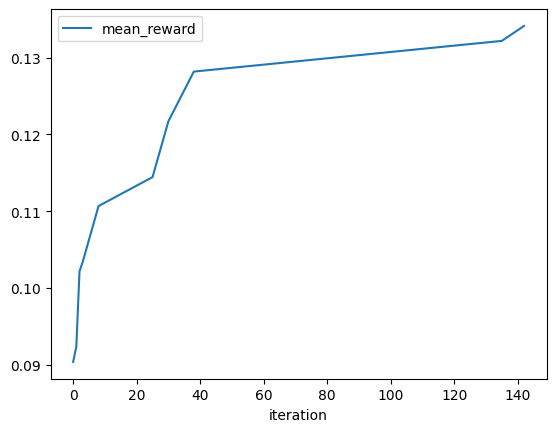

In [4]:
df_filtered.plot(x="iteration", y="mean_reward")

In [52]:
df_1 = pd.read_csv("baseline_samples_2/sample_inference_result_theta_1_max_rate_15.csv")
df_2 = pd.read_csv("best_samples/sample_inference_result_theta_1_max_rate_15.csv")

In [53]:
df_1

,ymd,hm,theta_origin,theta_next
0,2025-03-23,2025-10-14 14:00:00,69.908,70.010979
1,2025-03-23,2025-10-14 14:00:00,68.348,68.297841
2,2025-03-23,2025-10-14 14:00:00,67.149,66.693263
3,2025-03-23,2025-10-14 14:00:00,66.293,66.169135
4,2025-03-23,2025-10-14 14:00:00,65.871,65.601224
...,...,...,...,...
1844,2025-03-23,2025-10-14 14:00:00,55.601,55.934864
1845,2025-03-23,2025-10-14 14:00:00,55.729,56.231807
1846,2025-03-23,2025-10-14 14:00:00,55.977,55.933606
1847,2025-03-23,2025-10-14 14:00:00,56.378,56.117959


In [54]:
df_2

,ymd,hm,theta_origin,theta_next
0,2025-03-23,2025-10-14 14:00:00,69.908,69.876807
1,2025-03-23,2025-10-14 14:00:00,68.348,68.316810
2,2025-03-23,2025-10-14 14:00:00,67.149,67.117812
3,2025-03-23,2025-10-14 14:00:00,66.293,64.849865
4,2025-03-23,2025-10-14 14:00:00,65.871,62.666141
...,...,...,...,...
1844,2025-03-23,2025-10-14 14:00:00,55.601,51.738249
1845,2025-03-23,2025-10-14 14:00:00,55.729,51.866247
1846,2025-03-23,2025-10-14 14:00:00,55.977,52.235760
1847,2025-03-23,2025-10-14 14:00:00,56.378,53.798369
